# Evasion Detection using BERT with Length-Aware Classification

This notebook demonstrates how to build and train a BERT-based model to detect evasive answers to interview questions, incorporating answer length as an additional feature.

## Environment Setup

This section sets a random seed for reproducibility and checks for GPU availability.

In [1]:
SEED = 158

In [2]:
import tensorflow as tf

# Get the GPU device name.
device_name = tf.test.gpu_device_name()

# The device name should look like the following:
if device_name == '/device:GPU:0':
    print('Found GPU at: {}'.format(device_name))
else:
    raise SystemError('GPU device not found')

2026-04-30 17:45:08.708806: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777571108.914088      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777571108.975153      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777571109.480210      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777571109.480247      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777571109.480249      22 computation_placer.cc:177] computation placer alr

Found GPU at: /device:GPU:0


I0000 00:00:1777571136.372175      22 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777571136.378792      22 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
import torch

# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 2 GPU(s) available.
We will use the GPU: Tesla T4


In [4]:
!pip install transformers

from transformers import pipeline

print(pipeline('sentiment-analysis')('hugging face is the best'))
[{'label': 'POSITIVE', 'score': 0.9998704791069031}]

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.999839186668396}]


[{'label': 'POSITIVE', 'score': 0.9998704791069031}]

# Data Loading and Preprocessing

Here, the dataset containing interview questions and answers is loaded. The `input_text` is created by concatenating the question and interview answer, and the shapes of the training and testing datasets are displayed.

In [5]:
import pandas as pd
from datasets import load_dataset, DatasetDict, Dataset, DatasetInfo

splits = {'train': 'data/train-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
train = pd.read_parquet("hf://datasets/ailsntua/QEvasion/" + splits["train"])
test = pd.read_parquet("hf://datasets/ailsntua/QEvasion/" + splits["test"])


train["input_text"] = train["question"] + " [SEP] " + train["interview_answer"]
test["input_text"] = test["question"] + " [SEP] " + test["interview_answer"]

print("Train shape:", train.shape)
print("Test shape: ", test.shape)

train.head(3)

Train shape: (3448, 21)
Test shape:  (308, 21)


,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,...,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label,input_text
0,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,How would you respond to the accusation that t...,...,None,None,None,False,False,False,0,Clear Reply,Explicit,How would you respond to the accusation that t...
1,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,Do you think President Xi is being sincere abo...,...,None,None,None,False,False,False,1,Ambivalent,General,Do you think President Xi is being sincere abo...
2,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Do you believe the country's slowdown and gro...,...,None,None,None,False,False,False,2,Ambivalent,Partial/half-answer,Do you believe the country's slowdown and gro...


#Data Analysis

This section visualizes the distribution of clarity labels in the training set and analyzes the average answer length for each label, providing insights into the dataset's characteristics.

Label Distribution

--Train--
clarity_label
Ambivalent         2040
Clear Reply        1052
Clear Non-Reply     356
Name: count, dtype: int64


Text(0.5, 0, 'Clarity Label')

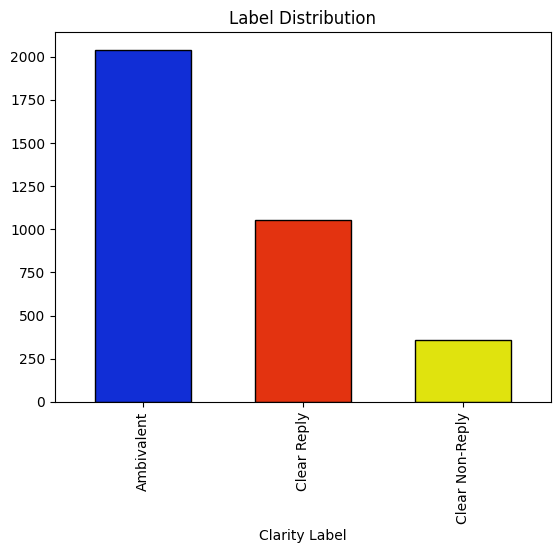

In [6]:
import matplotlib.pyplot as plt

print("Label Distribution\n")

print("--Train--")
print(train["clarity_label"].value_counts())

label_counts = train["clarity_label"].value_counts()
label_counts.plot(kind="bar", color=["#112ED6", "#E33310", "#E0E30E"], edgecolor="black", width=0.6)
plt.title("Label Distribution")
plt.xlabel("Clarity Label")

<Figure size 800x500 with 0 Axes>

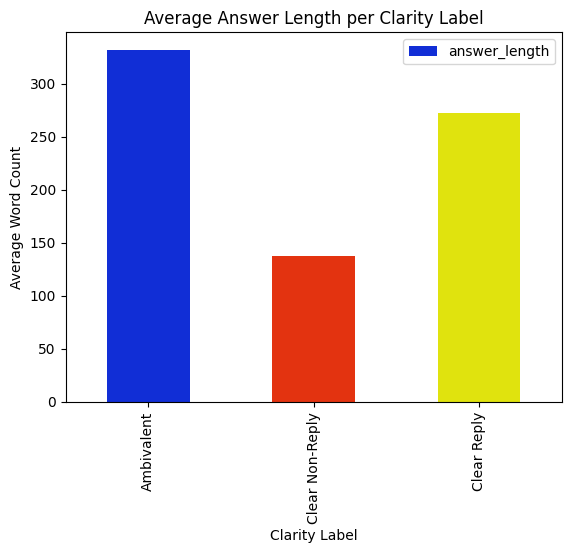

In [7]:
train["answer_length"] = train["interview_answer"].apply(lambda x: len(x.split()))

avg_lengths = train.groupby("clarity_label")["answer_length"].mean().reset_index()

plt.figure(figsize=(8, 5))
avg_lengths.plot(kind="bar", color=["#112ED6", "#E33310", "#E0E30E"], x="clarity_label", y="answer_length")
plt.title("Average Answer Length per Clarity Label")
plt.xlabel("Clarity Label")
plt.ylabel("Average Word Count")
plt.show()

# Tokenization and Feature Engineering

This section uses the `BertTokenizer` to tokenize the `interview_answer` and calculate token lengths. It also maps the `clarity_label` to numerical `label_id` and computes class weights to handle potential class imbalance during training.

In [8]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print('Computing answer token lengths...')

train_answer_lengths = []
for _, row in train.iterrows():
    a_ids = tokenizer.encode(str(row['interview_answer']), add_special_tokens=False)
    train_answer_lengths.append(len(a_ids))

test_answer_lengths = []
for _, row in test.iterrows():
    a_ids = tokenizer.encode(str(row['interview_answer']), add_special_tokens=False)
    test_answer_lengths.append(len(a_ids))

train_answer_lengths = torch.tensor(train_answer_lengths, dtype=torch.float)
test_answer_lengths  = torch.tensor(test_answer_lengths,  dtype=torch.float)

print('Train answer lengths shape:', train_answer_lengths.shape)
print('Test answer lengths shape :', test_answer_lengths.shape)
print('Mean answer length (tokens):', train_answer_lengths.mean().item())
print('Std answer length (tokens) :', train_answer_lengths.std().item())

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (591 > 512). Running this sequence through the model will result in indexing errors


Computing answer token lengths...
Train answer lengths shape: torch.Size([3448])
Test answer lengths shape : torch.Size([308])
Mean answer length (tokens): 376.91009521484375
Std answer length (tokens) : 382.4709167480469


In [9]:
LABEL2ID = {"Ambivalent": 0, "Clear Reply": 1, "Clear Non-Reply": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = len(LABEL2ID)

train["label_id"] = train["clarity_label"].map(LABEL2ID)

print("Label mapping:", LABEL2ID)

Label mapping: {'Ambivalent': 0, 'Clear Reply': 1, 'Clear Non-Reply': 2}


In [10]:
import numpy as np
import torch

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight="balanced",classes=np.array([0, 1, 2]),y=train["label_id"].values)
class_weights = torch.tensor(class_weights, dtype=torch.float)

print(f"\nClass weights: {class_weights}")


Class weights: tensor([0.5634, 1.0925, 3.2285])


Further tokenization is performed on the combined `question` and `interview_answer` to determine the distribution of token lengths, which helps in setting appropriate `max_length` for the model input. It also shows how many examples fit within common maximum token lengths.

In [11]:
token_lengths = []
for _, row in train.iterrows():
    tokens = tokenizer(str(row["question"]), str(row["interview_answer"]), truncation=False, add_special_tokens=True)
    token_lengths.append(len(tokens["input_ids"]))

train["token_length"] = token_lengths

print(f"\nToken length statistics:")
print(train["token_length"].describe().round(1))
print(f"\n% examples that fit within 512 tokens : {(train['token_length'] <= 512).mean()*100:.1f}%")
print(f"% examples that fit within 256 tokens : {(train['token_length'] <= 256).mean()*100:.1f}%")
print(f"Max token length in dataset           : {train['token_length'].max()}")


Token length statistics:
count    3448.0
mean      397.2
std       385.0
min         7.0
25%        95.0
50%       291.0
75%       582.2
max      2595.0
Name: token_length, dtype: float64

% examples that fit within 512 tokens : 70.6%
% examples that fit within 256 tokens : 46.0%
Max token length in dataset           : 2595


# Dataset Preparation for Model Input

The `input_text` (question + answer) is tokenized using BERT's tokenizer. The tokenized inputs, attention masks, labels, and computed `answer_lengths` are then converted into PyTorch tensors to create a `TensorDataset`. This dataset is split into training and validation sets, and `DataLoaders` are created for batching during training and evaluation.

In [12]:
# Tokenize and include answer_lengths
sentences = train["input_text"].values
labels = train["label_id"].values
lengths = train_answer_lengths.cpu().numpy()  # Use token lengths to match test set and normalisation constant

input_ids = []
attention_masks = []

for sent in sentences:
    encoded_dict = tokenizer(
                        sent,
                        add_special_tokens = True,
                        max_length = 512,
                        padding = 'max_length',
                        truncation = True,
                        return_attention_mask = True,
                        return_tensors = 'pt',
                   )
    input_ids.append(encoded_dict['input_ids'])
    attention_masks.append(encoded_dict['attention_mask'])

input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
labels = torch.tensor(labels)
answer_lengths = torch.tensor(lengths, dtype=torch.float)

print('Original: ', sentences[0])
print('Token IDs:', input_ids[0])

Original:  How would you respond to the accusation that the United States is containing China while pushing for diplomatic talks? [SEP] Well, look, first of all, theI am sincere about getting the relationship right. And one of the things that is going on now is, China is beginning to change some of the rules of the game, in terms of trade and other issues.And so one of the things we talked about, for example, is that they're now talking about making sure that no Chineseno one in the Chinese Government can use a Western cell phone. Those kinds of things.And so, really, what this trip was aboutit was less about containing China. I don't want to contain China. I just want to make sure that we have a relationship with China that is on the up and up, squared away, everybody knows what it's all about. And one of the ways you do that is, you make sure that we are talking about the same things.And I think that one of the things we've doneI've tried to do, and I've talked with a number of my st

In [13]:
from torch.utils.data import TensorDataset, random_split

dataset = TensorDataset(input_ids, attention_masks, labels, answer_lengths)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print('{:>5,} training samples'.format(train_size))
print('{:>5,} validation samples'.format(val_size))

3,103 training samples
  345 validation samples


In [14]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

batch_size = 16

train_dataloader = DataLoader(train_dataset, sampler = RandomSampler(train_dataset), batch_size = batch_size)

validation_dataloader = DataLoader(val_dataset, sampler = SequentialSampler(val_dataset), batch_size = batch_size)

# Model Definition

This section defines the `LengthAwareClassifier`, which wraps a BERT-based model and augments its final classification layer with the normalized answer length feature. The base BERT model `BertForSequenceClassification` is loaded and moved to the GPU.

In [15]:
from transformers import BertForSequenceClassification, BertConfig
from torch.optim import AdamW

import torch.nn as nn

class LengthAwareClassifier(nn.Module):

    def __init__(self, base_model, num_labels):
        super().__init__()
        self.transformer = base_model
        self.num_labels  = num_labels

        hidden_size = base_model.config.hidden_size

        self.classifier = nn.Linear(hidden_size + 1, num_labels)

    def forward(self, input_ids, attention_mask, answer_lengths=None, labels=None, **kwargs):
        outputs = self.transformer.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            **kwargs
        ) if hasattr(self.transformer, 'bert') else self.transformer.deberta(
            input_ids=input_ids,
            attention_mask=attention_mask,
            **kwargs
        ) if hasattr(self.transformer, 'deberta') else self.transformer.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            **kwargs
        )

        cls_output = outputs.last_hidden_state[:, 0, :]

        if answer_lengths is not None:
            normalized_lengths = (answer_lengths / 2595.0).unsqueeze(1).to(cls_output.device)
        else:
            normalized_lengths = torch.zeros(cls_output.size(0), 1).to(cls_output.device)

        combined = torch.cat([cls_output, normalized_lengths], dim=1)

        logits = self.classifier(combined)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
            loss = loss_fn(logits, labels)

        # Return in HuggingFace style
        from transformers.modeling_outputs import SequenceClassifierOutput
        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states if hasattr(outputs, 'hidden_states') else None,
            attentions=outputs.attentions if hasattr(outputs, 'attentions') else None
        )

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels = 3,
    output_attentions = False,
    output_hidden_states = False,
)

model = LengthAwareClassifier(model, num_labels=3)
model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


LengthAwareClassifier(
  (transformer): BertForSequenceClassification(
    (bert): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-11): 12 x BertLayer(
            (attention): BertAttention(
              (self): BertSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=768, out_

# Optimizer and Scheduler

An `AdamW` optimizer is configured for the model, and a linear learning rate scheduler with warm-up is created to dynamically adjust the learning rate during training, which can help in achieving better model performance.

In [16]:
optimizer = AdamW(model.parameters(),lr = 2e-5, eps = 1e-8)

from transformers import get_linear_schedule_with_warmup

epochs = 4

total_steps = len(train_dataloader) * epochs

scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps = 0, num_training_steps = total_steps)

# Training Loop

This section implements the training loop for the model. It iterates over multiple epochs, performing forward and backward passes, calculating loss, updating model parameters, and adjusting the learning rate. It also includes a validation step after each epoch to monitor the model's performance on unseen data, reporting accuracy, validation loss, and Macro F1 score.

In [17]:
import numpy as np
import time
import datetime

def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def format_time(elapsed):
    elapsed_rounded = int(round((elapsed)))
    return str(datetime.timedelta(seconds=elapsed_rounded))

In [18]:
import random
from sklearn.metrics import f1_score

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

training_stats = []

total_t0 = time.time()

for epoch_i in range(0, epochs):

    print("")
    print('======== Epoch {:} / {:} ========'.format(epoch_i + 1, epochs))
    print('Training...')

    t0 = time.time()

    # Reset the total loss for this epoch.
    total_train_loss = 0

    model.train()

    for step, batch in enumerate(train_dataloader):

        # Progress update every 40 batches.
        if step % 40 == 0 and not step == 0:

            elapsed = format_time(time.time() - t0)

            # Report progress.
            print('  Batch {:>5,}  of  {:>5,}.    Elapsed: {:}.'.format(step, len(train_dataloader), elapsed))

        b_input_ids  = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels     = batch[2].to(device)
        b_answer_lengths = batch[3].to(device)

        model.zero_grad()

        result = model(b_input_ids,
                       attention_mask=b_input_mask,
                       answer_lengths=b_answer_lengths,
                       labels=b_labels,
                       return_dict=True)

        loss = result.loss
        logits = result.logits

        total_train_loss += loss.item()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        # Update the learning rate.
        scheduler.step()

    # Calculate the average loss over all of the batches.
    avg_train_loss = total_train_loss / len(train_dataloader)

    # Measure how long this epoch took.
    training_time = format_time(time.time() - t0)

    print("")
    print("  Average training loss: {0:.2f}".format(avg_train_loss))
    print("  Training epoch took: {:}".format(training_time))

    # ========================================
    #               Validation
    # ========================================
    # After the completion of each training epoch, measure our performance on
    # our validation set.

    print("")
    print("Running Validation...")

    t0 = time.time()

    model.eval()

    total_eval_accuracy = 0
    total_eval_loss     = 0
    nb_eval_steps       = 0

    # Collect all predictions and true labels for Macro F1 at epoch end.
    predictions  = []
    true_labels  = []

    # Evaluate data for one epoch
    for batch in validation_dataloader:

        b_input_ids  = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels     = batch[2].to(device)
        b_answer_lengths = batch[3].to(device)

        with torch.no_grad():

            result = model(b_input_ids,
                           attention_mask=b_input_mask,
                           answer_lengths=b_answer_lengths,
                           labels=b_labels,
                           return_dict=True)

        loss = result.loss
        logits = result.logits

        total_eval_loss += loss.item()

        logits    = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        total_eval_accuracy += flat_accuracy(logits, label_ids)

        # Store predictions and true labels for Macro F1 calculation.
        predictions.append(logits)
        true_labels.append(label_ids)

    # Report the final accuracy for this validation run.
    avg_val_accuracy = total_eval_accuracy / len(validation_dataloader)
    print("  Accuracy: {0:.2f}".format(avg_val_accuracy))

    avg_val_loss = total_eval_loss / len(validation_dataloader)

    validation_time = format_time(time.time() - t0)

    flat_predictions = np.argmax(np.concatenate(predictions, axis=0), axis=1).flatten()
    flat_true_labels = np.concatenate(true_labels, axis=0)
    val_macro_f1     = f1_score(flat_true_labels, flat_predictions, average='macro')

    print("  Validation Loss: {0:.2f}".format(avg_val_loss))
    print("  Macro F1:        {0:.4f}".format(val_macro_f1))
    print("  Validation took: {:}".format(validation_time))

    # Record all statistics from this epoch.
    training_stats.append(
        {
            'epoch': epoch_i + 1,
            'Training Loss': avg_train_loss,
            'Valid. Loss': avg_val_loss,
            'Valid. Accur.': avg_val_accuracy,
            'Valid. Macro F1': val_macro_f1,
            'Training Time': training_time,
            'Validation Time': validation_time
        }
    )

print("")
print("Training complete!")

print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))


======== Epoch 1 / 4 ========
Training...
  Batch    40  of    194.    Elapsed: 0:00:58.
  Batch    80  of    194.    Elapsed: 0:02:06.
  Batch   120  of    194.    Elapsed: 0:03:13.
  Batch   160  of    194.    Elapsed: 0:04:21.

  Average training loss: 1.00
  Training epoch took: 0:05:18

Running Validation...
  Accuracy: 0.59
  Validation Loss: 0.87
  Macro F1:        0.5452
  Validation took: 0:00:13

======== Epoch 2 / 4 ========
Training...
  Batch    40  of    194.    Elapsed: 0:01:07.
  Batch    80  of    194.    Elapsed: 0:02:15.
  Batch   120  of    194.    Elapsed: 0:03:23.
  Batch   160  of    194.    Elapsed: 0:04:31.

  Average training loss: 0.76
  Training epoch took: 0:05:28

Running Validation...
  Accuracy: 0.62
  Validation Loss: 0.92
  Macro F1:        0.5407
  Validation took: 0:00:13

======== Epoch 3 / 4 ========
Training...
  Batch    40  of    194.    Elapsed: 0:01:07.
  Batch    80  of    194.    Elapsed: 0:02:14.
  Batch   120  of    194.    Elapsed: 0:03:

# Training Statistics and Visualization

After training, the statistics from each epoch (training loss, validation loss, accuracy, Macro F1, and time taken) are collected into a DataFrame and displayed. A plot is generated to visualize the training and validation loss over epochs, helping to identify potential overfitting or underfitting.

In [19]:
pd.options.display.precision = 2

df_stats = pd.DataFrame(data=training_stats)

df_stats = df_stats.set_index('epoch')

df_stats

,Training Loss,Valid. Loss,Valid. Accur.,Valid. Macro F1,Training Time,Validation Time
epoch,,,,,,
1,1.00,0.87,0.59,0.55,0:05:18,0:00:13
2,0.76,0.92,0.62,0.54,0:05:28,0:00:13
3,0.61,0.97,0.60,0.59,0:05:28,0:00:13
4,0.48,0.99,0.62,0.60,0:05:28,0:00:13


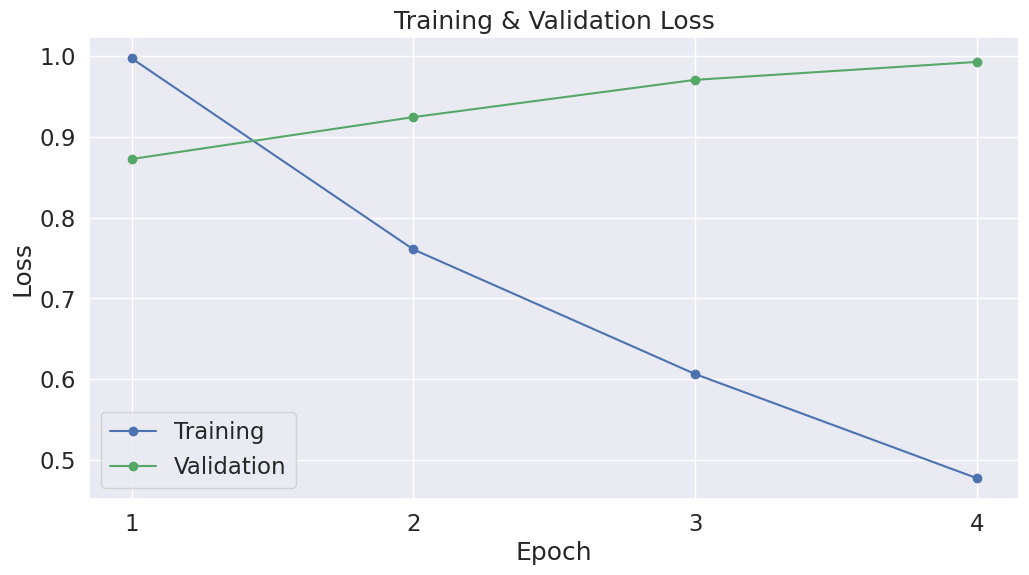

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

# Plot the learning curve.
plt.plot(df_stats['Training Loss'], 'b-o', label="Training")
plt.plot(df_stats['Valid. Loss'], 'g-o', label="Validation")

# Label the plot.
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.xticks([1, 2, 3, 4])

plt.show()

# Test Set Prediction and Evaluation

This section prepares the test dataset for prediction by tokenizing `input_text` and generating `input_ids` and `attention_masks`. The model is then used to predict labels for the test sentences. The Matthews Correlation Coefficient (MCC) is calculated for each batch and overall to assess the model's performance on the test set, especially in cases of imbalanced classes.

In [21]:
test["label_id"] = test["clarity_label"].map(LABEL2ID)

df = test
# Report the number of test sentences.
print('Number of test sentences: {:,}\n'.format(test.shape[0]))

# Create sentence and label lists from the TEST set
sentences = test["input_text"].values
labels = test["label_id"].values
# Use the pre-computed test_answer_lengths from cell SRbEoDUraPDr
lengths = test_answer_lengths.cpu().numpy()

input_ids = []
attention_masks = []

# For every sentence in the TEST set...
for sent in sentences:
    encoded_dict = tokenizer(
                        sent,                      # Sentence to encode.
                        add_special_tokens = True, # Add '[CLS]' and '[SEP]'
                        max_length = 512,          # Use consistent max_length as training
                        padding = 'max_length',
                        truncation = True,
                        return_attention_mask = True,   # Construct attn. masks.
                        return_tensors = 'pt',     # Return pytorch tensors.
                   )
    input_ids.append(encoded_dict['input_ids'])
    attention_masks.append(encoded_dict['attention_mask'])

# Convert the lists into tensors.
input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
labels = torch.tensor(labels)
answer_lengths = torch.tensor(lengths, dtype=torch.float) # Use pre-computed test_answer_lengths

batch_size = 32

# Include answer_lengths in the TensorDataset for test prediction
prediction_data = TensorDataset(input_ids, attention_masks, labels, answer_lengths)
prediction_sampler = SequentialSampler(prediction_data)
prediction_dataloader = DataLoader(prediction_data, sampler=prediction_sampler, batch_size=batch_size)

Number of test sentences: 308



In [22]:
print('Predicting labels for {:,} test sentences...'.format(len(input_ids)))

# Put model in evaluation mode
model.eval()

predictions , true_labels = [], []

# Predict
for batch in prediction_dataloader:

  batch = tuple(t.to(device) for t in batch)

  b_input_ids, b_input_mask, b_labels, b_answer_lengths = batch

  with torch.no_grad():
      result = model(b_input_ids,
                     token_type_ids=None,
                     attention_mask=b_input_mask,
                     answer_lengths=b_answer_lengths,
                     return_dict=True)

  logits = result.logits

  logits = logits.detach().cpu().numpy()
  label_ids = b_labels.to('cpu').numpy()

  predictions.append(logits)
  true_labels.append(label_ids)

print('    DONE.')

Predicting labels for 308 test sentences...
    DONE.


In [23]:
print('Class distribution in test set:')
print(df['clarity_label'].value_counts())
print(df['label_id'].value_counts().sort_index())

Class distribution in test set:
clarity_label
Ambivalent         206
Clear Reply         79
Clear Non-Reply     23
Name: count, dtype: int64
label_id
0    206
1     79
2     23
Name: count, dtype: int64


In [24]:
from sklearn.metrics import matthews_corrcoef

matthews_set = []

print('Calculating Matthews Corr. Coef. for each batch...')

# For each input batch...
for i in range(len(true_labels)):
  pred_labels_i = np.argmax(predictions[i], axis=1).flatten()

  try:
      matthews = matthews_corrcoef(true_labels[i], pred_labels_i)
  except Exception:
      matthews = 0.0
  matthews_set.append(matthews)

Calculating Matthews Corr. Coef. for each batch...


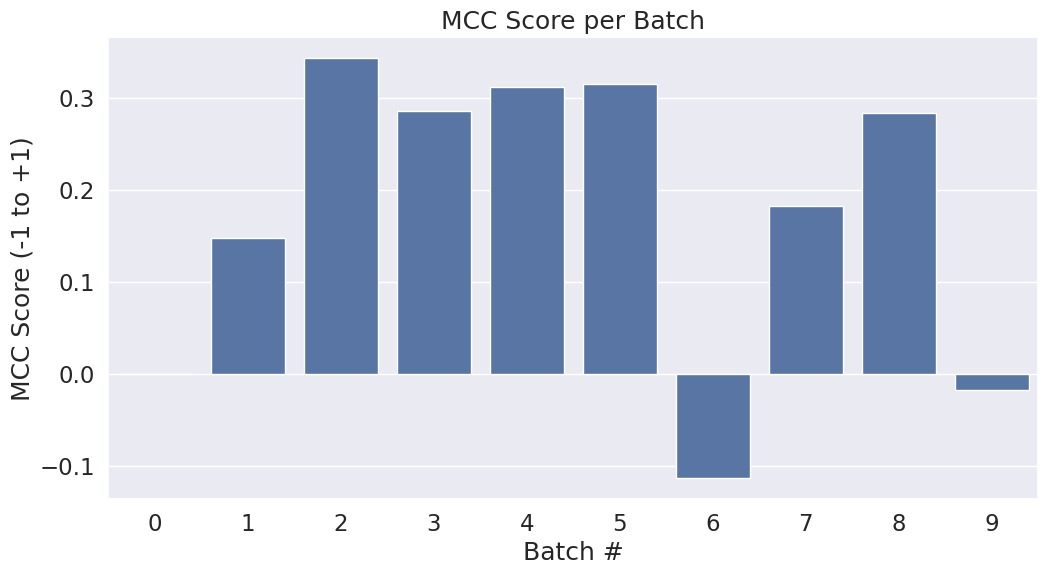

In [25]:
# Create a barplot showing the MCC score for each batch of test samples.
ax = sns.barplot(x=list(range(len(matthews_set))), y=matthews_set, errorbar=None)

plt.title('MCC Score per Batch')
plt.ylabel('MCC Score (-1 to +1)')
plt.xlabel('Batch #')

plt.show()

In [26]:
# Combine the results across all batches.
flat_predictions = np.concatenate(predictions, axis=0)

# For each sample, pick the label (0 or 1) with the higher score.
flat_predictions = np.argmax(flat_predictions, axis=1).flatten()

# Combine the correct labels for each batch into a single list.
flat_true_labels = np.concatenate(true_labels, axis=0)

# Calculate the MCC
mcc = matthews_corrcoef(flat_true_labels, flat_predictions)

print('Total MCC: %.3f' % mcc)

Total MCC: 0.204


# Kaggle submition

In [27]:
# Map numeric predictions back to label names
predicted_labels = [ID2LABEL[pred] for pred in flat_predictions]

submission = pd.DataFrame({
    "Id": test["index"],
    "Predicted": predicted_labels
})

submission.to_csv("submission_bert-base-uncased.csv", index=False)
print(submission.head(10))

   Id        Predicted
0   0       Ambivalent
1   1       Ambivalent
2   2       Ambivalent
3   3       Ambivalent
4   4      Clear Reply
5   5       Ambivalent
6   6  Clear Non-Reply
7   7       Ambivalent
8   8       Ambivalent
9   9       Ambivalent


In [28]:
submission.to_csv("submission.csv", index=False)
print("Submission completed.")
print('\nFirst 10 rows:')
print(submission.head(10))

Submission completed.

First 10 rows:
   Id        Predicted
0   0       Ambivalent
1   1       Ambivalent
2   2       Ambivalent
3   3       Ambivalent
4   4      Clear Reply
5   5       Ambivalent
6   6  Clear Non-Reply
7   7       Ambivalent
8   8       Ambivalent
9   9       Ambivalent
